# **Business Overview**

Beacon Community Capital is a Treasury-certified Community Development Financial Institution (a **CDFI**) based in Columbus, Ohio.

Its mission is to lend small personal and small-business loans to the people big banks turn away: borrowers with a thin credit history, or a past stumble that dented their score but who are reliable today. A single mother rebuilding after a medical bankruptcy. A food-truck owner whose income is real but irregular. These are Beacon's customers.

Today, every single application is read and decided **by hand** by a team of five loan officers.

The mission is working, and that is the problem. As word has spread, applications have climbed from about **500 a month to roughly 1,800 a month**. The five officers cannot keep up. A decision that should take a day now takes **three to four days**, and good applicants are giving up and walking away while they wait.

# **The Challenge**

Two things are breaking at once: speed and consistency.

**Speed.** Five people reading 1,800 files a month by hand cannot move fast. The backlog grows every week.

**Consistency.** A recent internal review pulled a stack of past files and had a second officer re-decide them blind. The result was uncomfortable: about **1 in 5 files** would have been decided differently by the second officer. Same application, same numbers, different answer, depending only on who happened to pick it up.

The team once tried the obvious shortcut: a flat rule that approves anyone with a **FICO score of 660 or higher** and rejects everyone else. It failed, and it failed in the worst possible way. That rule rejected exactly the borrowers Beacon exists to serve: the self-employed applicant with a modest score but strong savings and a steady income. A blunt score cut-off cannot see the whole person.

So Beacon needs something **faster than three days** and **more consistent than five people deciding by hand**, without going back to a blunt rule that turns away its own customers.

# **Objective**

You are going to build a **first-pass sorter** for incoming applications.

For each application, the sorter reads the whole file and returns one of two answers, **approve** or **reject**, together with a **confidence level**: how sure it is, expressed as an approval probability between 0 and 1.

The confidence level decides what happens next:

| Confidence (approval probability) | What happens |
|---|---|
| **Above 0.80** | Clears automatically as an **approve** |
| **Below 0.20** | Clears automatically as a **reject** |
| **Between 0.20 and 0.80** | **Flagged to a human officer** to decide |

The two easy piles clear instantly, so the five officers spend their time only on the genuinely borderline files. These cut-offs are set by the business, not by the model.

**In scope:** a trained, evaluated model plus this decision rule.
**Out of scope:** plugging it into Beacon's live systems. That is a later project.

# **The One Thing You Must Never Forget**

Read this slowly, because it changes how you think about everything below.

The model learns from Beacon's **past decisions**. It studies applications that officers already approved or rejected, and it learns to **copy that pattern**. That single fact has two heavy consequences:

**1. The model copies past decisions. It does not predict who will repay.** It is not a crystal ball for default risk. It is a mirror of how officers have decided before. So if past officers were ever unfair, even by accident, the model will quietly learn that unfairness and repeat it at scale, 1,800 times a month. This is exactly why the middle confidence band exists: a **human officer must own every rejection.**

**2. Fair-lending law (ECOA) applies.** The model must never use race, age, or address. And you must stay alert to ordinary-looking columns that could secretly stand in for those things.

Keep this in the back of your mind through the whole build. You are automating a fair-lending decision. Fairness is the **first** question here, not a footnote.

# **Your Build, in Four Stages**

You will build this like a story, and each chapter sets up the next:

1. **Explore and Clean** - meet the data, see what is wrong with it, and fix it. You cannot trust a model built on messy data.
2. **Business Insights** - draw graphs and pull out plain facts, so you actually understand who gets approved and why. This is also where you answer the fairness questions.
3. **Model Training** - train one logistic regression model to copy the officers' good decisions.
4. **Evaluation** - measure it with one honest number, accuracy, prove it beats the old flat rule, and see how many files it could clear without a human.

Run the notebook top to bottom. Every stage depends on the one before it.

# **How You Will Work: AI-Assisted Coding**

You will **not** be handed the code, and you will **not** be handed ready-made prompts. Writing the right prompt is the whole skill this project is teaching, and your prompt trail is what we grade most heavily.

For each code step you will see three things:
1. **A short explanation** in a markdown cell, telling you *what* the step must do and *why* it comes now.
2. **A code cell with `##` instructions** describing what to build and what to ask Codex for, with a few blanks (`______`) to show you the structure. This is your starting point, not the answer.
3. **An "Expected result"** telling you the number or picture you should get, so you can check your own work.

**Your job at every code step:**
- Read the explanation and the `##` instructions in the cell.
- **Write your own clear prompt to Codex** (in VS Code) asking it to produce that piece of code.
- Paste Codex's code into the cell, replacing the `______` blanks, and run it.
- Check your output against the **Expected result**. If it is wrong, fix your prompt and try again, that back-and-forth is exactly what earns marks.

**Three habits that protect your Codex credits. Follow them every single time:**
- **Never paste the full CSV into Codex.** It is 232 rows and will burn your credits fast. Describe the columns instead, the instructions already name them for you.
- If you ever must show Codex real data, **paste at most about 20 rows**, never the whole file.
- **Reuse what you already built.** Do not reload or re-clean data you cleaned a few cells ago. Each step builds on the last.

**What you submit:** run the finished notebook top to bottom, export it to a single **HTML file**, and submit that, along with your **full Codex prompt trail** (every prompt you sent, starting with your Stage 0 planning prompt).

# **Stage 0 - Give Codex the Plan (Do This First)**

Good AI-assisted work starts before any code. First you tell your AI partner the **whole story**, so every later prompt lands in context instead of arriving cold.

Your first task is to write a **planning prompt**: a single message to Codex that hands over the full project context (the business, the data columns, the fairness constraint, and the four-stage plan) and asks it for a step-by-step build plan, **without writing any code yet**.

Everything you need is on this page above: the business overview, the objective, the fairness rule, the four stages, and the column list you will meet in Stage 1. Put those into your own words in the prompt.

**This planning prompt is the first and most important entry in your prompt trail.** Write it, send it to Codex, read the plan it gives back, and check it matches the four stages. Then move on to Setup below and build that plan stage by stage.

*(Tip: end your planning prompt with a guardrail line telling Codex never to ask you to paste the full CSV, only to work from the column descriptions.)*

# **Setup - Load the Tools**

Every project starts by loading its tools. **This one is done for you**, run the two cells below as they are. We use **pandas** for the data table, **matplotlib** and **seaborn** for the graphs, and a few pieces of **scikit-learn** to build and check the model.

In [1]:
# If any of these libraries are missing in your environment, uncomment the line below and run it once.
!pip install -q pandas numpy matplotlib seaborn scikit-learn


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Data handling
import pandas as pd
import numpy as np

# Charts
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning tools from scikit-learn
from sklearn.model_selection import train_test_split   # splits data into train and test sets
from sklearn.linear_model import LogisticRegression    # the model we will train
from sklearn.metrics import accuracy_score             # measures how often the model is right

# Make the charts look clean and show them inside the notebook
sns.set_style("whitegrid")
%matplotlib inline

# **Stage 1 - Explore and Clean the Data**

Here is the golden rule of every data project: **look before you leap.** A model trained on messy data gives confident, messy answers, and in lending that means unfair decisions. So before we build anything, we meet the data and repair it.

The dataset is a single file, `loan_applications.csv`. Each row is one loan application. Here is what every column means:

| Column | What it means |
|---|---|
| `applicant_id` | Unique ID for the applicant (e.g. BCC-1066) |
| `fico_score` | Credit score, roughly 300 to 850 |
| `annual_income` | Yearly income, in dollars |
| `loan_amount` | Amount requested, in dollars |
| `loan_term_months` | Months to repay |
| `employment_status` | Salaried or Self-employed |
| `years_employed` | Years in current employment |
| `savings_balance` | Money in savings, in dollars |
| `approved` | The past decision: Approved or Rejected (**this is what the model learns to copy**) |

### Step 1.1 - Load the data and check its size

First we load the file into a table (a pandas DataFrame) and check how big it is.

This step is to read and understand what the size of the data set is and to look at the first few rows which will help us moving forward with the next steps

**Expected result:** 232 rows and 9 columns.

In [3]:
# Load the data into a DataFrame
df = pd.read_csv('loan_applications.csv')

# Print the shape (rows and columns)
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")

Dataset shape: 232 rows, 9 columns


### Step 1.2 - Look at the first few rows

Numbers in a shape tell us how big the table is. Now we actually look at it, to see what real rows look like.

In [4]:
# Print the first 5 rows
print("\nFirst 5 rows:")
print(df.head(5))


First 5 rows:
  applicant_id  fico_score annual_income loan_amount  loan_term_months  \
0     BCC-1219         NaN         69100       12000                48   
1     BCC-1066       646.0         64900       19500                24   
2     BCC-1009       610.0         50500        9200                36   
3     BCC-1170       624.0         20000       10800                12   
4     BCC-1015       610.0         41000       10400                36   

  employment_status  years_employed savings_balance  approved  
0     Self-employed              20           19200  Approved  
1          Salaried              12           21100  Approved  
2     Self-employed              12            7300  Approved  
3          Salaried              11            8700  Approved  
4          Salaried              17            3800  Approved  


### Step 1.3 - Check column types and missing values

This one command is the most useful in all of data cleaning. It tells us, for every column, its **data type** and how many values are filled in. We are hunting for two red flags: **money columns stored as text**, and **columns with missing values**.

**Expected result:** the three money columns show up as text (object), and fico_score has fewer filled-in values than the rest.

In [5]:
# Check column data types, non-null values, and missing values
df.info()

df.dtypes

df.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 232 entries, 0 to 231
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   applicant_id       232 non-null    str    
 1   fico_score         222 non-null    float64
 2   annual_income      232 non-null    str    
 3   loan_amount        232 non-null    str    
 4   loan_term_months   232 non-null    int64  
 5   employment_status  232 non-null    str    
 6   years_employed     232 non-null    int64  
 7   savings_balance    232 non-null    str    
 8   approved           232 non-null    str    
dtypes: float64(1), int64(2), str(6)
memory usage: 16.4 KB


applicant_id          0
fico_score           10
annual_income         0
loan_amount           0
loan_term_months      0
employment_status     0
years_employed        0
savings_balance       0
approved              0
dtype: int64

### Step 1.4 - Summary statistics

Now we look at the range of each number column: its smallest value, largest value, and average. This is the fastest way to catch **impossible values**, like a negative income or a 999-month loan term.

**Expected result:** you will spot a max FICO above 850, a negative minimum income, an impossible max loan term, and an impossible max "years employed".

In [6]:
# Display summary statistics for all numeric and categorical columns
df.describe(include='all')

,applicant_id,fico_score,annual_income,loan_amount,loan_term_months,employment_status,years_employed,savings_balance,approved
count,232,222.000000,232,232,232.000000,232,232.000000,232,232
unique,220,NaN,176,177,NaN,2,NaN,162,2
top,BCC-1019,NaN,20000,50000,NaN,Salaried,NaN,17400,Approved
freq,2,NaN,20,6,NaN,142,NaN,4,141
mean,NaN,666.941441,NaN,NaN,42.439655,NaN,9.771552,NaN,NaN
std,NaN,65.383942,NaN,NaN,90.969886,NaN,14.160627,NaN,NaN
min,NaN,521.000000,NaN,NaN,12.000000,NaN,0.000000,NaN,NaN
25%,NaN,619.750000,NaN,NaN,24.000000,NaN,5.000000,NaN,NaN
50%,NaN,663.500000,NaN,NaN,36.000000,NaN,8.000000,NaN,NaN
75%,NaN,704.000000,NaN,NaN,48.000000,NaN,12.000000,NaN,NaN


### Step 1.5 - See the missing values as a picture

Tables are easy to skim past. A picture is not. Let's draw a bar chart of how many values are missing in each column, so the gap is impossible to miss.

**Expected result:** one clear bar, `fico_score` has 10 missing values, everything else has none.

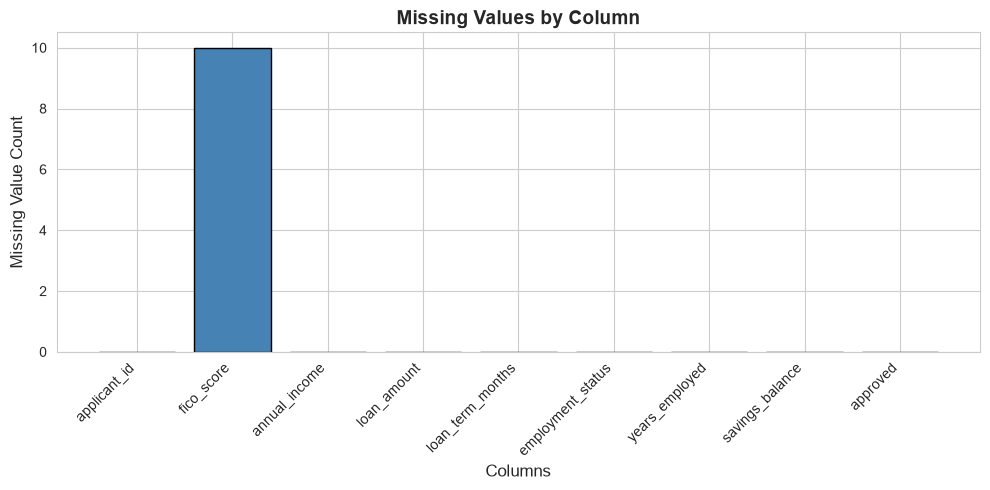

In [7]:
# Create a bar chart of missing values by column
missing_counts = df.isnull().sum()
plt.figure(figsize=(10, 5))
plt.bar(missing_counts.index, missing_counts.values, color='steelblue', edgecolor='black')
plt.title('Missing Values by Column', fontsize=14, fontweight='bold')
plt.ylabel('Missing Value Count', fontsize=12)
plt.xlabel('Columns', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Your Observations: Read the Raw Data (4 points)

Before we fix anything, write **five plain-English points** about what you have seen so far (Steps 1.1 to 1.5), in your own words. This is graded on whether your points are **true to the data**, not on fancy writing.

Ideas to comment on: how many applications there are, what one row represents, which columns are numbers and which are categories, what looks messy or wrong, and what the `approved` column is for.

1. The dataset contains 232 rows and 9 columns each representing a loan application
2. The first few rows show that the dataset includes different data types such as numeric fields and categorical fields and what are the values that each column holds
3. By checking the data types and missing values, we get an understanding of where the data stands. It shows that multiple fields which are supposed to be numeric are all text and 10 missing values in FICO_SCORE which need cleaning
4. Digging deeper into looking at the statistics helps us understand the type of values within each column. This shows us some impossible values such as fico_score, years_employed and so on which needs to be cleaned.
5. To have a better understanding, we built a graph to give a better context in case of missing values so that it is easier to understand and interpret the next steps moving forward. 

## Cleaning: Fix the Four Problems, In Order

Your exploration turned up exactly four problems. We fix them in a **fixed order**, and it matters that you do the same four fixes the same way, so your cleaned data comes out right for the steps that follow.

1. **Money stored as text** -> turn into plain numbers.
2. **Duplicate applications** -> remove them.
3. **Impossible values** -> remove those rows.
4. **Missing FICO scores** -> fill them in.

### Fix 1 - Money stored as text

Some money values are written like `"$53,000"`. Python cannot do maths on text, so those columns were treated as text. We strip the `$` and the comma and turn them into real numbers.

In [8]:
# All the three money columns
money_cols = ['annual_income', 'loan_amount', 'savings_balance']

for col in money_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(r"[\$,]", "", regex=True)  # remove $ and commas
        .replace("nan", pd.NA)                  # keep real missing as NA if any
    )
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Double-check dtypes
df[money_cols].dtypes

annual_income      int64
loan_amount        int64
savings_balance    int64
dtype: object

### Fix 2 - Remove duplicate applications

Some rows are exact copies of another row. A duplicate would let the same application count twice and bias the model. We drop exact duplicates.

**Expected result:** 12 duplicates removed, **220 rows** remain.

In [9]:
# Record the initial number of rows
initial_rows = df.shape[0]

# Drop exact duplicate rows
df = df.drop_duplicates()

# Reset the index
df = df.reset_index(drop=True)

# Calculate how many duplicates were removed
duplicates_removed = initial_rows - df.shape[0]

# Print results
print(f"Initial number of rows: {initial_rows}")
print(f"Duplicates removed: {duplicates_removed}")
print(f"Rows remaining: {df.shape[0]}")

Initial number of rows: 232
Duplicates removed: 12
Rows remaining: 220


### Fix 3 - Remove rows with impossible values

`describe()` showed values that cannot be real. These are data-entry errors, and we cannot know the true value, so we remove those few rows. Be careful: we remove rows where a value is **present but impossible**, not rows where FICO is simply blank (those are handled next).

**Expected result:** 8 rows removed, **212 rows** remain.

In [10]:
# Record initial row count
initial_rows = df.shape[0]

# Remove rows where ANY of these conditions are true:
# - fico_score > 850 (and fico_score is not NaN)
# - annual_income < 0
# - loan_amount <= 0
# - loan_term_months > 84
# - years_employed > 60
# - savings_balance < 0

mask_invalid = (
    ((df['fico_score'] > 850) & (df['fico_score'].notna())) |  # FICO > 850 but NOT blank
    (df['annual_income'] < 0) |
    (df['loan_amount'] <= 0) |
    (df['loan_term_months'] > 84) |
    (df['years_employed'] > 60) |
    (df['savings_balance'] < 0)
)

# Remove rows with impossible values (keep rows where mask is False)
df = df[~mask_invalid]

# Reset the index
df = df.reset_index(drop=True)

# Calculate and print results
rows_removed = initial_rows - df.shape[0]
print(f"Initial number of rows: {initial_rows}")
print(f"Rows removed (impossible values): {rows_removed}")
print(f"Rows remaining: {df.shape[0]}")

Initial number of rows: 220
Rows removed (impossible values): 8
Rows remaining: 212


### Fix 4 - Fill in the missing FICO scores

A few applications have a blank FICO score. We will not drop them (that throws away good applications) and cannot leave them blank (the model needs a number). We fill each blank with the **median** FICO, a safe, standard choice.

**Expected result:** 10 blanks filled, **0 missing** afterwards.

In [11]:
# Count missing FICO scores before filling
missing_before = df['fico_score'].isna().sum()

# Calculate the median FICO score
fico_median = df['fico_score'].median()

# Fill missing FICO scores with the median (using the proper pandas approach)
df['fico_score'] = df['fico_score'].fillna(fico_median)

# Count missing FICO scores after filling
missing_after = df['fico_score'].isna().sum()

# Print results
print(f"Missing FICO scores before filling: {missing_before}")
print(f"Missing FICO scores after filling: {missing_after}")
print(f"FICO scores filled: {missing_before}")
print(f"Median FICO score used: {fico_median}")

Missing FICO scores before filling: 10
Missing FICO scores after filling: 0
FICO scores filled: 10
Median FICO score used: 662.0


### Step 1.6 - Confirm the data is clean

One final check before we move on: the right number of rows, and not a single missing value anywhere.

**Expected result:** **212 rows**, 9 columns, and **0 missing values**.

In [12]:
# Print the shape of the dataframe
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")

# Print the total number of missing values across the entire table
total_missing = df.isnull().sum().sum()
print(f"Total missing values: {total_missing}")

Dataset shape: 212 rows, 9 columns
Total missing values: 0


# **Stage 2 - Business Insights**

The data is clean, so now we can trust what it tells us. In this stage we draw graphs and pull out plain facts about **who gets approved and why**. These pictures are how you will understand the business, and they are what you will lean on to answer the fairness questions at the end of this stage.

### Step 2.1 - How many were approved vs rejected?

The first question any lender asks: what share of applications get a yes? We count both outcomes and draw them as a bar chart.

**Expected result:** about **60% approved** (roughly 127 Approved, 85 Rejected).

Counts:
 approved
Approved    127
Rejected     85
Name: count, dtype: int64

Approval rate: 59.91%


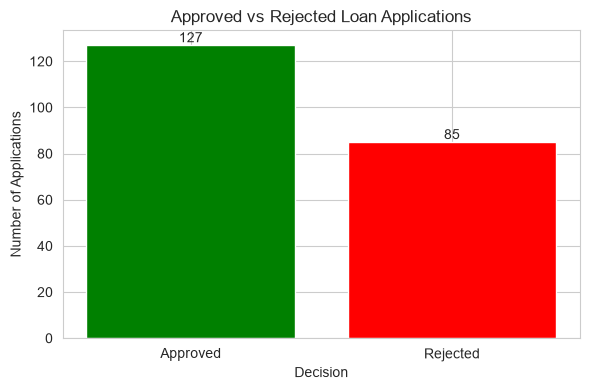

In [13]:
# Counts
decision_counts = df["approved"].value_counts()
print("Counts:\n", decision_counts)

# Approval percentage
approved_count = int(decision_counts.get("Approved", 0))
total_count = int(decision_counts.sum())
approved_rate = approved_count / total_count if total_count else 0
print(f"\nApproval rate: {approved_rate:.2%}")

# Bar chart
labels = ["Approved", "Rejected"]
values = [int(decision_counts.get("Approved", 0)), int(decision_counts.get("Rejected", 0))]
colors = ["green", "red"]

plt.figure(figsize=(6, 4))
bars = plt.bar(labels, values, color=colors)
plt.title("Approved vs Rejected Loan Applications")
plt.xlabel("Decision")
plt.ylabel("Number of Applications")

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, f"{int(height)}",
             ha="center", va="bottom")

plt.tight_layout()
plt.show()

### Step 2.2 - What do the credit scores look like?

Beacon serves thin- and bruised-credit borrowers, so we expect a wide spread of FICO scores, not just high ones. Let's see the actual shape with a histogram.

**Expected result:** a spread across the whole range, with a clear chunk of applicants **below 660**, the borrowers the old flat rule would reject.

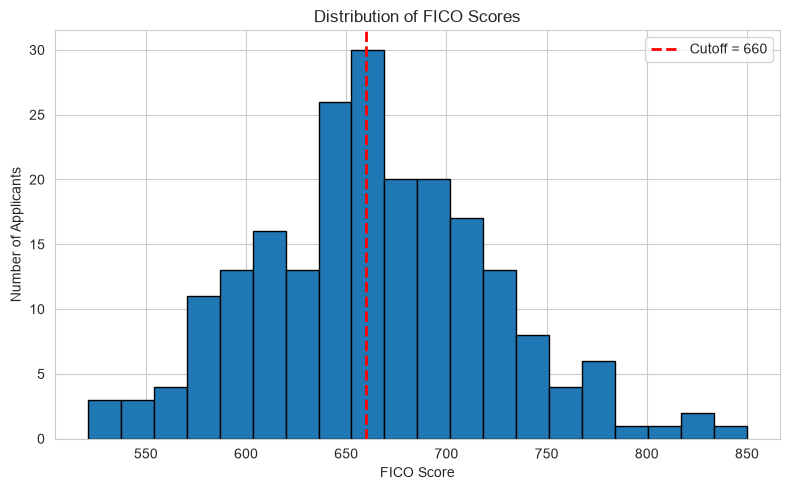

In [14]:
# Create a histogram of FICO scores
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(df["fico_score"], bins=20, edgecolor="black")
plt.axvline(660, color="red", linestyle="--", linewidth=2, label="Cutoff = 660")

plt.title("Distribution of FICO Scores")
plt.xlabel("FICO Score")
plt.ylabel("Number of Applicants")
plt.legend()

plt.tight_layout()
plt.show()

### Step 2.3 - Does approval depend on employment type?

Beacon exists partly to serve **self-employed** borrowers. If the data approved them at a very different rate from salaried applicants, that would be worth knowing.

Approval rate by employment_status (%):
employment_status
Salaried         64.89
Self-employed    51.85
Name: approved_num, dtype: float64


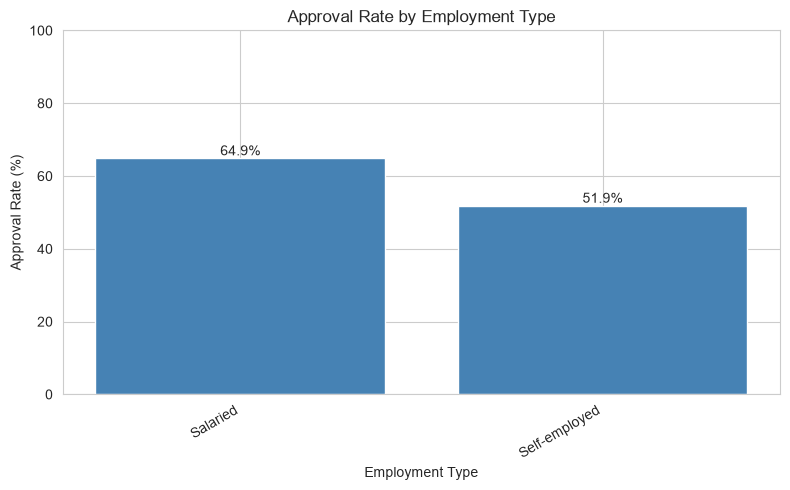

In [15]:
# Approval rate by employment type (as %)
approval_rate_by_emp = (
    df.assign(approved_num=(df["approved"] == "Approved").astype(int))
      .groupby("employment_status")["approved_num"]
      .mean()
      .sort_values(ascending=False)
      .mul(100)
)

print("Approval rate by employment_status (%):")
print(approval_rate_by_emp.round(2))

# Bar chart
plt.figure(figsize=(8, 5))
bars = plt.bar(approval_rate_by_emp.index, approval_rate_by_emp.values, color="steelblue")

plt.title("Approval Rate by Employment Type")
plt.xlabel("Employment Type")
plt.ylabel("Approval Rate (%)")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 100)

for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, h, f"{h:.1f}%", ha="center", va="bottom")

plt.tight_layout()
plt.show()

### Step 2.4 - Do approved applicants just have higher scores?

If FICO alone decided everything, the old flat rule would have worked. Let's test that directly: compare the FICO scores of approved vs rejected applicants with a box plot. If the boxes overlap a lot, FICO alone is **not** enough.

**Expected result:** approved applicants score a little higher, **but the two boxes overlap heavily**, which is exactly why a one-number rule fails.

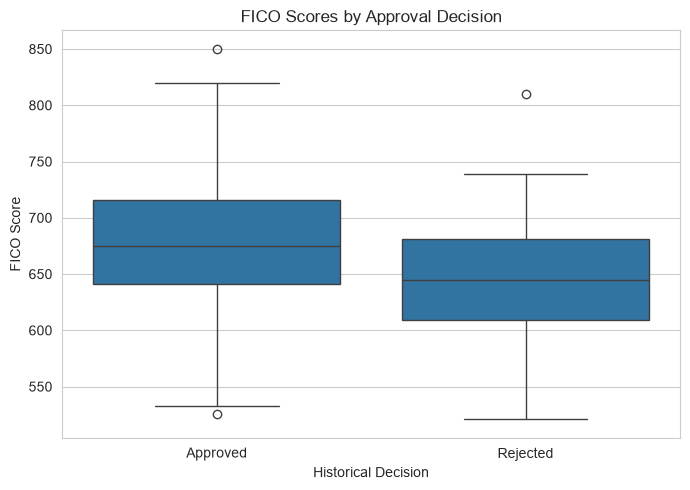

In [16]:
## TASK: FICO by decision.
## Prompt Codex to draw a seaborn box plot of fico_score split by the approved column
## (Approved vs Rejected on the x-axis, fico_score on the y-axis), with a title and axis labels.

# Create a box plot comparing FICO scores by approval decision
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="approved", y="fico_score")

plt.title("FICO Scores by Approval Decision")
plt.xlabel("Historical Decision")
plt.ylabel("FICO Score")

plt.tight_layout()
plt.show()

### Step 2.5 - Which numbers move together?

A correlation heatmap shows which columns rise and fall together. It helps you see that approval is linked to several columns at once, not just FICO.

**Expected result:** approval is positively linked with fico_score, income, and savings, no single column dominates.

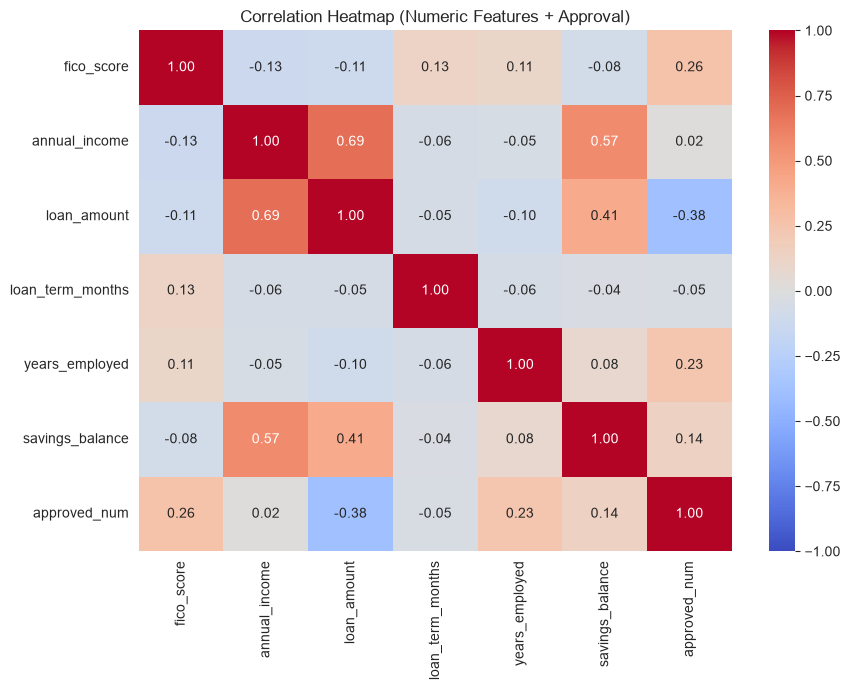

In [17]:
#Creating a copy of df
df_corr = df.copy()
df_corr["approved_num"] = (df_corr["approved"] == "Approved").astype(int)

#All the numeric columns
numeric_cols = [
    "fico_score",
    "annual_income",
    "loan_amount",
    "loan_term_months",
    "years_employed",
    "savings_balance",
    "approved_num",
]

corr = df_corr[numeric_cols].corr()

#The plot size and look
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Heatmap (Numeric Features + Approval)")
plt.tight_layout()
plt.show()

# **Stage 3 - Model Training (6 Marks)**

Now we build the sorter itself. We will train one **logistic regression** model. It is a great fit here: it is simple to understand, and it naturally produces a **probability** for each application, which is exactly the confidence level our decision rule needs (the 0.20 and 0.80 cut-offs).

### Step 3.1 - Turn the decision into a number

Models work with numbers, not words. We turn the `approved` column into 1 (Approved) and 0 (Rejected). This new column is the **answer** the model will learn to predict.

In [18]:
## TASK: Turn the decision into a number.
## Prompt Codex to create a new column in df called approved_flag that is 1 where approved is
## "Approved" and 0 otherwise, then show the count of each value.

# Create numeric target: 1 = Approved, 0 = Rejected
df["approved_flag"] = df["approved"].astype(str).str.strip().str.lower().map(
    {"approved": 1, "rejected": 0}
)

# Confirm conversion counts
print(df["approved_flag"].value_counts(dropna=False))

approved_flag
1    127
0     85
Name: count, dtype: int64


### Step 3.2 - Choose the input columns (and leave out the dangerous ones)

Now we choose the columns the model may look at (the **features**) and separate the answer (the **target**).

Two columns must be left out, and knowing *why* is part of the lesson:
- **`applicant_id`** is just a label with no meaning.
- **`approved` / `approved_flag`** is the answer itself. Giving it to the model as an input would be **cheating** (this mistake is called "leakage").

In [19]:
# Select the six numeric features that will be used as model inputs.
# We leave out applicant_id because it is only an identifier,
# and we leave out approved / approved_flag because those are the answers we are trying to predict.
feature_cols = [
    "fico_score",
    "annual_income",
    "loan_amount",
    "loan_term_months",
    "years_employed",
    "savings_balance",
]

# Create X using only the selected input features.
X = df[feature_cols].copy()

# Convert employment_status into a numeric feature.
# Self-employed applicants are coded as 1, and all others are coded as 0.
X["is_self_employed"] = (df["employment_status"] == "Self-employed").astype(int)

# Create y as the target variable the model will learn to predict.
y = df["approved_flag"].copy()

# Check the size of the input table.
# X should have 212 rows and 7 features in this project.
print("X shape:", X.shape)

X shape: (212, 7)


### Step 3.3 - Split into training and test sets

We train on 80% of the data and hide 20% to test honestly. `stratify=y` keeps the same approve/reject balance in both halves, and `random_state=42` makes the split the same every time, so your results stay stable each time you run it.

**Expected result:** about **169 training rows** and **43 test rows**.

In [20]:
# Import the function used to split the data
from sklearn.model_selection import train_test_split

# Split the data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42,
)

# Check the number of rows in each set
print("Training rows:", X_train.shape[0])
print("Test rows:", X_test.shape[0])

Training rows: 169
Test rows: 43


### Step 3.4 - Train the model

Now we train (the technical word is **fit**) the logistic regression on the training data. This is the moment the model learns the officers' pattern.

In [21]:
# Import Logistic Regression
from sklearn.linear_model import LogisticRegression

# Create the model
model = LogisticRegression(max_iter=1000)

# Train the model
model.fit(X_train, y_train)

# Confirm training is complete
print("Logistic Regression model training complete.")

Logistic Regression model training complete.


### Step 3.5 - Which factors push toward approval?

A logistic regression is not a black box, we can read what it learned. Each feature gets a weight (a **coefficient**): positive pushes toward approval, negative pushes toward rejection.

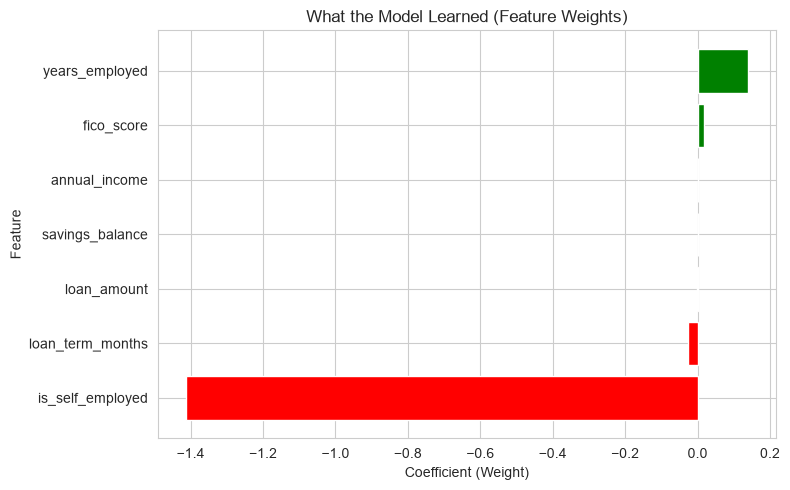

In [22]:
# Create a table with each feature and its model coefficient
coef_df = pd.DataFrame({
    "feature": X.columns,
    "coefficient": model.coef_[0],
}).sort_values("coefficient", ascending=True)

coef_df

# Use green for positive weights and red for negative weights
colors = ["green" if c > 0 else "red" for c in coef_df["coefficient"]]

# Plot the feature weights
plt.figure(figsize=(8, 5))
plt.barh(coef_df["feature"], coef_df["coefficient"], color=colors)
plt.title("What the Model Learned (Feature Weights)")
plt.xlabel("Coefficient (Weight)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### Step 3.6 - Which parameter matters most, fairly compared

One catch with the chart above: `annual_income` is measured in tens of thousands and `years_employed` in single digits, so their raw weights are not directly comparable. To compare fairly, we put every column on the same scale first, then read the weights off a **separate** copy of the model. This does **not** change your main model or its accuracy.

**Expected result:** `annual_income` and `fico_score` come out as the strongest positive factors.

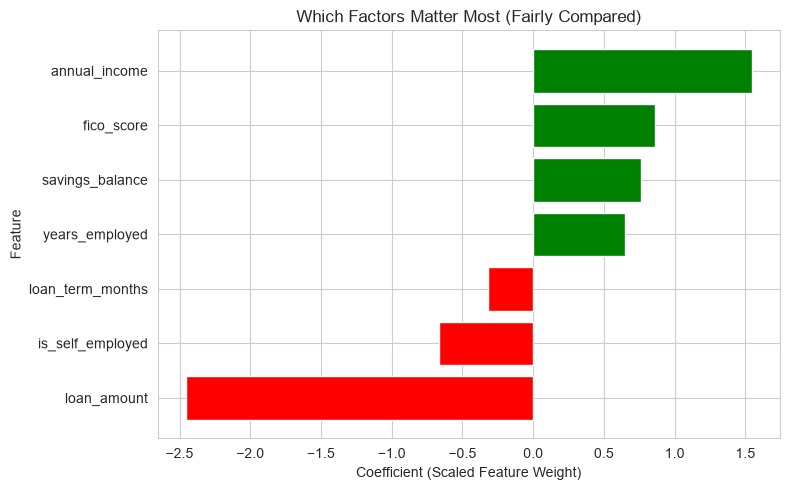

In [23]:
from sklearn.preprocessing import StandardScaler

# Fit scaler ONLY on X_train (do not overwrite X_train / X_test)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # created for later use if needed

# Train a separate model on the SCALED training data
importance_model = LogisticRegression(max_iter=1000)
importance_model.fit(X_train_scaled, y_train)

# Coefficient table (scaled => more comparable)
importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "coefficient": importance_model.coef_[0],
}).sort_values("coefficient", ascending=True)

importance_df

# Horizontal bar chart
colors = ["green" if c > 0 else "red" for c in importance_df["coefficient"]]

plt.figure(figsize=(8, 5))
plt.barh(importance_df["feature"], importance_df["coefficient"], color=colors)
plt.title("Which Factors Matter Most (Fairly Compared)")
plt.xlabel("Coefficient (Scaled Feature Weight)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# **Stage 4 - Evaluation (6 Marks)**

A model is only as good as its proof. We now measure the sorter with one honest number, **accuracy**, then do the two comparisons that matter to Beacon: is it better than the **old flat rule**, and how many files could it clear **without a human**?

### Step 4.1 - How accurate is the model?

Accuracy answers a simple question: of the 43 hidden test applications, what share did the model decide the same way the officers did?

**Expected result:** about **86%**.

In [24]:
# Make predictions on the test data
y_pred = model.predict(X_test)

# Calculate the model's accuracy
accuracy = accuracy_score(y_test, y_pred)

# Print accuracy as a percentage
print(f"Test accuracy: {accuracy * 100:.1f}%")

Test accuracy: 86.0%


### Step 4.2 - Beat the old flat rule (FICO >= 660)

Remember Beacon's failed shortcut: approve if FICO is 660 or higher. Let's measure how accurate that rule would be on the **same** test set, to prove the model is genuinely better.

**Expected result:** about **65%**, well below the model.

In [25]:
# Apply the old FICO >= 660 approval rule
flat_rule_pred = (X_test["fico_score"] >= 660).astype(int)

# Calculate the flat rule accuracy
flat_rule_accuracy = accuracy_score(y_test, flat_rule_pred)

# Print the accuracy as a percentage
print(f"Flat rule test accuracy: {flat_rule_accuracy * 100:.1f}%")

Flat rule test accuracy: 65.1%


### Step 4.3 - Put all three side by side

The simplest possible "model" is to approve everyone. Since about 60% were approved, that is right about 60% of the time, the floor any real model must clear. Let's compute it and chart all three together.

**Expected result:** three bars, the model tallest at about 86%, the flat rule around 65%, the baseline around 60%.

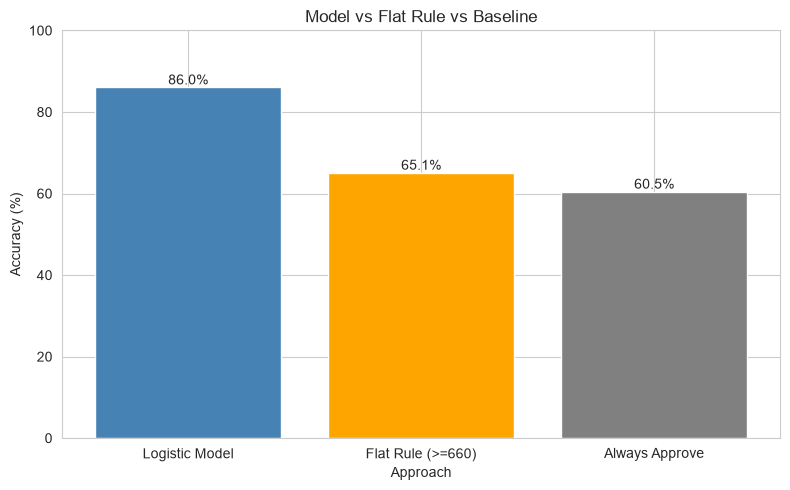

In [26]:
# Always-approve baseline (predict 1 for every test row)
baseline_pred = np.ones_like(y_test)
baseline_accuracy = accuracy_score(y_test, baseline_pred)

# Bar chart comparison (percent)
labels = ["Logistic Model", "Flat Rule (>=660)", "Always Approve"]
values = [accuracy * 100, flat_rule_accuracy * 100, baseline_accuracy * 100]

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, values, color=["steelblue", "orange", "gray"])
plt.title("Model vs Flat Rule vs Baseline")
plt.xlabel("Approach")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)

for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, h, f"{h:.1f}%", ha="center", va="bottom")

plt.tight_layout()
plt.show()

### Step 4.4 - How many files could clear without a human?

This ties the whole project back to Beacon's real goal: freeing up the five officers. Using the model's **confidence** (its approval probability), we sort the test applications into three piles: auto-approve (above 0.80), auto-reject (below 0.20), and send-to-human (in between).

**Expected result:** most files land in the two auto piles and clear instantly, only the genuinely borderline ones go to a human.

Auto-approve     21
Send to human    14
Auto-reject       8
Name: count, dtype: int64


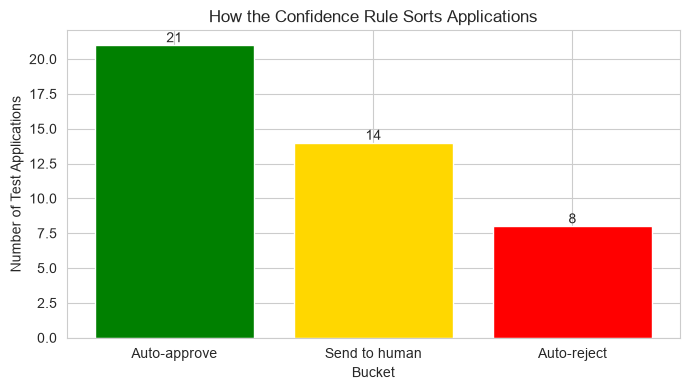

In [ ]:
# Probabilities of approval (class 1)
proba_approve = model.predict_proba(X_test)[:, 1]

# Bucket by business thresholds
buckets = pd.Series(proba_approve).apply(
    lambda p: "Auto-approve" if p > 0.80 else ("Auto-reject" if p < 0.20 else "Send to human")
)

bucket_counts = buckets.value_counts().reindex(["Auto-approve", "Send to human", "Auto-reject"], fill_value=0)
print(bucket_counts)

# Bar chart
plt.figure(figsize=(7, 4))
bars = plt.bar(bucket_counts.index, bucket_counts.values, color=["green", "gold", "red"])
plt.title("How the Confidence Rule Sorts Applications")
plt.xlabel("Bucket")
plt.ylabel("Number of Test Applications")

for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, h, str(int(h)), ha="center", va="bottom")

plt.tight_layout()
plt.show()


*Conclusion: The logistic regression model performed best with 86.0% accuracy, compared with 65.1% for the old FICO >= 660 rule and 60.5% for the always-approve baseline. The model beats the flat rule because it looks at several factors together, such as FICO score, income, savings, loan amount, employment status, and years employed. The box plot also shows a lot of overlap between approved and rejected applicants, so FICO alone is not enough to make a good decision. This is especially important for Beacon because it serves borrowers who may have lower credit scores but still have other strengths in their application.*